In [1]:
# Minimax Algorithm using Recursion

def minimax(depth, node_index, is_max, values, height):
    # If leaf node is reached
    if depth == height:
        return values[node_index]

    if is_max:
        return max(
            minimax(depth + 1, node_index * 2, False, values, height),
            minimax(depth + 1, node_index * 2 + 1, False, values, height)
        )
    else:
        return min(
            minimax(depth + 1, node_index * 2, True, values, height),
            minimax(depth + 1, node_index * 2 + 1, True, values, height)
        )


# Leaf node values
values = [3, 5, 2, 9, 12, 5, 23, 23]

# Height of complete binary tree
height = 3

# Find optimal score for MAX player
optimal_score = minimax(0, 0, True, values, height)

print("Optimal Score for MAX player:", optimal_score)

Optimal Score for MAX player: 12


In [6]:
import math

def minimax(depth, node_index, is_max, values, height):
    # Leaf node
    if depth == height:
        return values[node_index], [values[node_index]]

    if is_max:
        left_score, left_path = minimax(depth + 1, node_index * 2,
                                        False, values, height)
        right_score, right_path = minimax(depth + 1, node_index * 2 + 1,
                                          False, values, height)

        if left_score >= right_score:
            return left_score, [left_score] + left_path
        else:
            return right_score, [right_score] + right_path

    else:  # MIN player
        left_score, left_path = minimax(depth + 1, node_index * 2,
                                        True, values, height)
        right_score, right_path = minimax(depth + 1, node_index * 2 + 1,
                                          True, values, height)

        if left_score <= right_score:
            return left_score, [left_score] + left_path
        else:
            return right_score, [right_score] + right_path


# Leaf node values
values = [3, 5, 2, 9, 12, 5, 23, 23]

# Height of tree (8 leaves => height = 3)
height = int(math.log2(len(values)))

# Run Minimax
optimal_score, path = minimax(0, 0, True, values, height)

print("Optimal Score for MAX player:", optimal_score)
print("Optimal Path:", " -> ".join(map(str, path)))

Optimal Score for MAX player: 12
Optimal Path: 12 -> 12 -> 12 -> 12


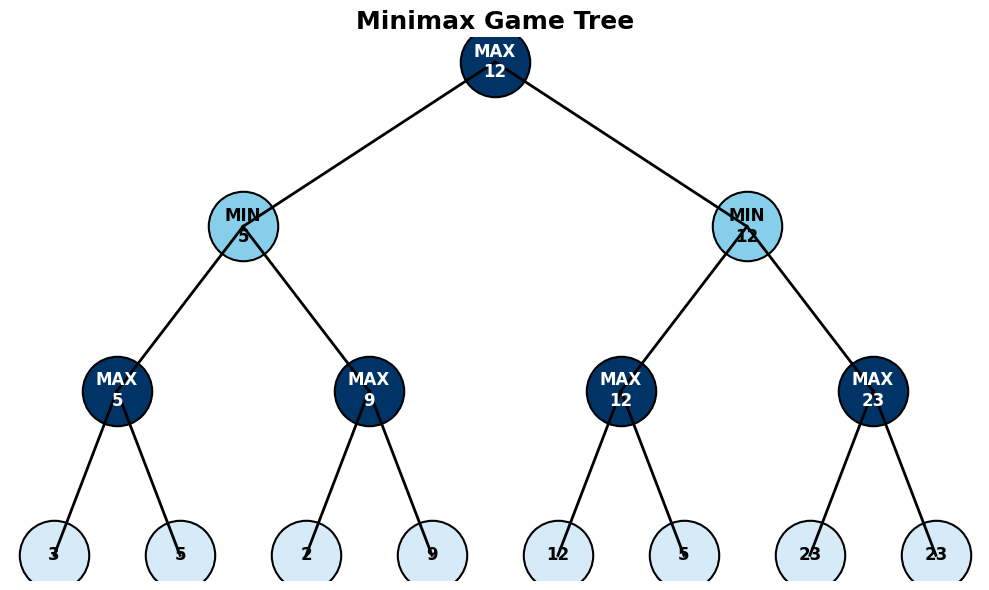

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Node positions
pos = {
    "MAX\n12_root": (0, 3),

    "MIN\n5": (-2, 2),
    "MIN\n12": (2, 2),

    "MAX\n5": (-3, 1),
    "MAX\n9": (-1, 1),
    "MAX\n12": (1, 1),
    "MAX\n23": (3, 1),

    "3": (-3.5, 0),
    "5": (-2.5, 0),
    "2": (-1.5, 0),
    "9": (-0.5, 0),
    "12": (0.5, 0),
    "5_leaf": (1.5, 0),
    "23": (2.5, 0),
    "23_leaf": (3.5, 0)
}

# Edges
edges = [
    ("MAX\n12_root", "MIN\n5"),
    ("MAX\n12_root", "MIN\n12"),

    ("MIN\n5", "MAX\n5"),
    ("MIN\n5", "MAX\n9"),

    ("MIN\n12", "MAX\n12"),
    ("MIN\n12", "MAX\n23"),

    ("MAX\n5", "3"),
    ("MAX\n5", "5"),

    ("MAX\n9", "2"),
    ("MAX\n9", "9"),

    ("MAX\n12", "12"),
    ("MAX\n12", "5_leaf"),

    ("MAX\n23", "23"),
    ("MAX\n23", "23_leaf")
]

# Draw edges
for p, c in edges:
    x1, y1 = pos[p]
    x2, y2 = pos[c]
    plt.plot([x1, x2], [y1, y2], color='black', linewidth=2)

# Draw nodes
for node, (x, y) in pos.items():

    if "MAX" in node:
        color = "#003366"      # Deep Blue
        text_color = "white"

    elif "MIN" in node:
        color = "#87CEEB"      # Sky Blue
        text_color = "black"

    else:                      # Leaf nodes
        color = "#D6EAF8"
        text_color = "black"

    plt.scatter(x, y, s=2500, color=color,
                edgecolors='black', linewidths=1.5)

    label = node.replace("_root", "").replace("_leaf", "")

    plt.text(x, y, label,
             ha='center',
             va='center',
             fontsize=12,
             fontweight='bold',
             color=text_color)

plt.title("Minimax Game Tree", fontsize=18, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

Optimal Score = 12
Optimal Leaf Index = 4


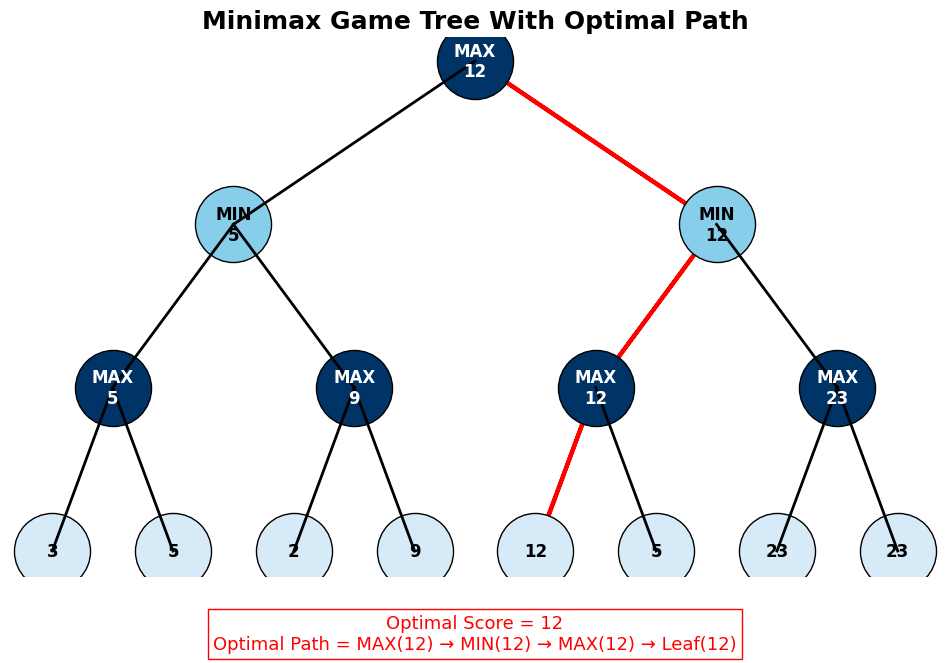

In [7]:
import math
import matplotlib.pyplot as plt

# -----------------------------
# Minimax with Path Tracking
# -----------------------------
def minimax(depth, index, is_max, values, height):

    if depth == height:
        return values[index], [index]

    left_score, left_path = minimax(
        depth + 1, index * 2, not is_max, values, height
    )

    right_score, right_path = minimax(
        depth + 1, index * 2 + 1, not is_max, values, height
    )

    if is_max:
        if left_score >= right_score:
            return left_score, [index] + left_path
        else:
            return right_score, [index] + right_path
    else:
        if left_score <= right_score:
            return left_score, [index] + left_path
        else:
            return right_score, [index] + right_path


# -----------------------------
# Leaf values
# -----------------------------
values = [3, 5, 2, 9, 12, 5, 23, 23]
height = int(math.log2(len(values)))

score, path = minimax(0, 0, True, values, height)

print("Optimal Score =", score)
print("Optimal Leaf Index =", path[-1])

# -----------------------------
# Tree Coordinates
# -----------------------------
pos = {
    "R": (0, 3),

    "M1": (-2, 2),
    "M2": (2, 2),

    "A1": (-3, 1),
    "A2": (-1, 1),
    "A3": (1, 1),
    "A4": (3, 1),

    "L1": (-3.5, 0),
    "L2": (-2.5, 0),
    "L3": (-1.5, 0),
    "L4": (-0.5, 0),
    "L5": (0.5, 0),
    "L6": (1.5, 0),
    "L7": (2.5, 0),
    "L8": (3.5, 0)
}

# -----------------------------
# Tree Edges
# -----------------------------
edges = [
    ("R","M1"),("R","M2"),

    ("M1","A1"),("M1","A2"),
    ("M2","A3"),("M2","A4"),

    ("A1","L1"),("A1","L2"),
    ("A2","L3"),("A2","L4"),
    ("A3","L5"),("A3","L6"),
    ("A4","L7"),("A4","L8")
]

# -----------------------------
# Optimal Path
# -----------------------------
optimal_edges = [
    ("R","M2"),
    ("M2","A3"),
    ("A3","L5")
]

# -----------------------------
# Draw Edges
# -----------------------------
plt.figure(figsize=(12,7))

for p,c in edges:
    x1,y1 = pos[p]
    x2,y2 = pos[c]

    if (p,c) in optimal_edges:
        plt.arrow(
            x1,y1,
            x2-x1,
            y2-y1,
            color='red',
            linewidth=3,
            length_includes_head=True,
            head_width=0.08
        )
    else:
        plt.plot([x1,x2],[y1,y2],
                 color='black',
                 linewidth=2)

# -----------------------------
# Draw Nodes
# -----------------------------
nodes = {
    "R":"MAX\n12",

    "M1":"MIN\n5",
    "M2":"MIN\n12",

    "A1":"MAX\n5",
    "A2":"MAX\n9",
    "A3":"MAX\n12",
    "A4":"MAX\n23",

    "L1":"3",
    "L2":"5",
    "L3":"2",
    "L4":"9",
    "L5":"12",
    "L6":"5",
    "L7":"23",
    "L8":"23"
}

for key,(x,y) in pos.items():

    label = nodes[key]

    if "MAX" in label:
        color = "#003366"     # Deep Blue
        txt = "white"

    elif "MIN" in label:
        color = "#87CEEB"     # Sky Blue
        txt = "black"

    else:
        color = "#D6EAF8"
        txt = "black"

    plt.scatter(
        x,y,
        s=3000,
        color=color,
        edgecolors='black'
    )

    plt.text(
        x,y,
        label,
        ha='center',
        va='center',
        fontsize=12,
        fontweight='bold',
        color=txt
    )

# -----------------------------
# Result
# -----------------------------
plt.text(
    0,-0.6,
    f"Optimal Score = {score}\nOptimal Path = MAX(12) → MIN(12) → MAX(12) → Leaf(12)",
    fontsize=13,
    color='red',
    ha='center',
    bbox=dict(facecolor='white', edgecolor='red')
)

plt.title("Minimax Game Tree With Optimal Path",
          fontsize=18,
          fontweight='bold')

plt.axis('off')
plt.show()

Optimal Score for MAX = 12
Pruned Branches = [7]


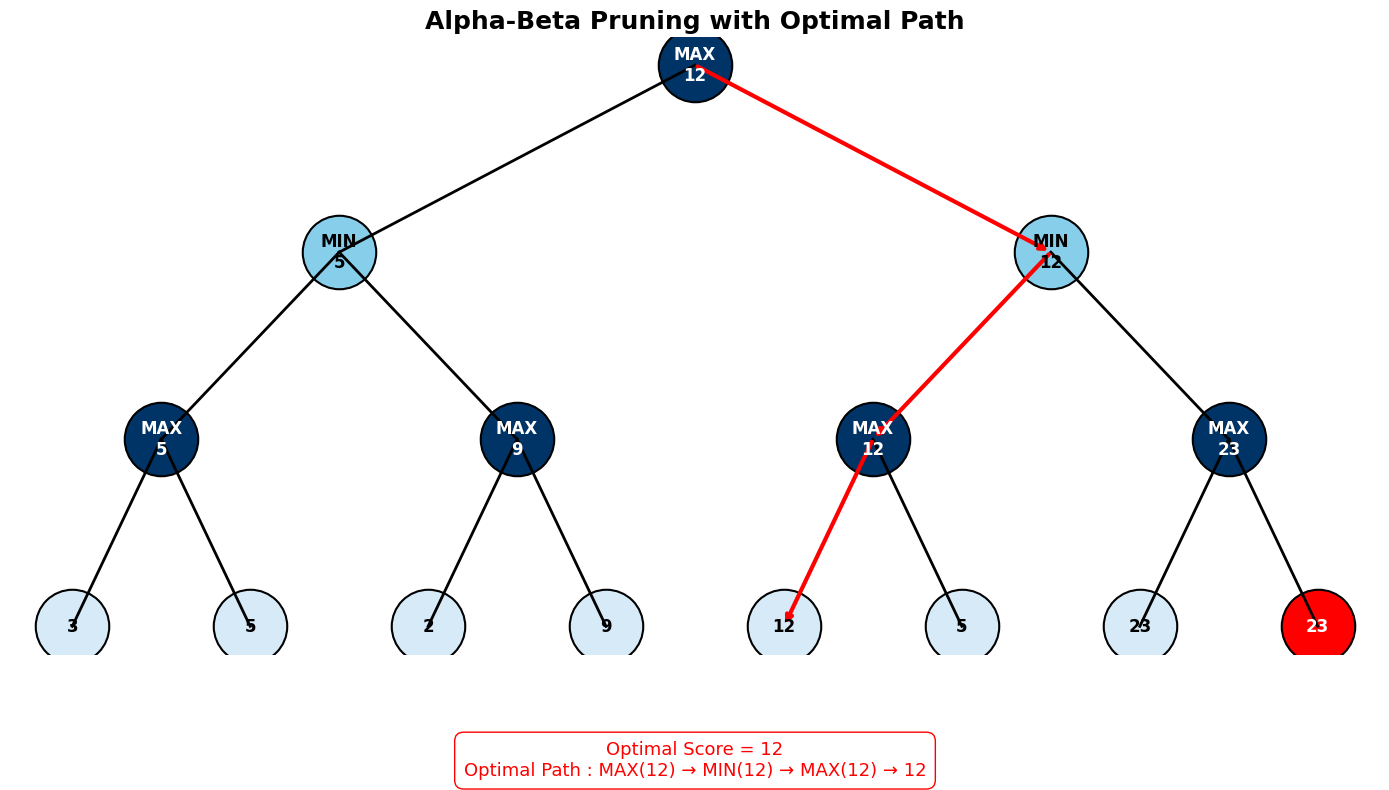

In [11]:
import math
import matplotlib.pyplot as plt

# ---------------------------------------
# Alpha-Beta Pruning
# ---------------------------------------

pruned_nodes = []

def alphabeta(depth, node_index, is_max, values, height, alpha, beta):

    if depth == height:
        return values[node_index]

    if is_max:

        best = -math.inf

        for i in range(2):

            child = node_index * 2 + i

            val = alphabeta(
                depth + 1,
                child,
                False,
                values,
                height,
                alpha,
                beta
            )

            best = max(best, val)
            alpha = max(alpha, best)

            if beta <= alpha:

                if i == 0:
                    pruned_nodes.append(child + 1)

                break

        return best

    else:

        best = math.inf

        for i in range(2):

            child = node_index * 2 + i

            val = alphabeta(
                depth + 1,
                child,
                True,
                values,
                height,
                alpha,
                beta
            )

            best = min(best, val)
            beta = min(beta, best)

            if beta <= alpha:

                if i == 0:
                    pruned_nodes.append(child + 1)

                break

        return best


# ---------------------------------------
# Input Leaf Values
# ---------------------------------------

leaf_values = [3, 5, 2, 9, 12, 5, 23, 23]

height = int(math.log2(len(leaf_values)))

optimal_score = alphabeta(
    0,
    0,
    True,
    leaf_values,
    height,
    -math.inf,
    math.inf
)

# ---------------------------------------
# Internal Node Values
# ---------------------------------------

max1 = max(3, 5)      # 5
max2 = max(2, 9)      # 9
max3 = max(12, 5)     # 12
max4 = max(23, 23)    # 23

min1 = min(max1, max2)    # 5
min2 = min(max3, max4)    # 12

root = max(min1, min2)    # 12

print("Optimal Score for MAX =", root)
print("Pruned Branches =", pruned_nodes)

# ---------------------------------------
# Node Positions
# ---------------------------------------

pos = {
    "R": (0, 3),

    "M1": (-2, 2),
    "M2": (2, 2),

    "A1": (-3, 1),
    "A2": (-1, 1),
    "A3": (1, 1),
    "A4": (3, 1),

    "L1": (-3.5, 0),
    "L2": (-2.5, 0),
    "L3": (-1.5, 0),
    "L4": (-0.5, 0),
    "L5": (0.5, 0),
    "L6": (1.5, 0),
    "L7": (2.5, 0),
    "L8": (3.5, 0)
}

# ---------------------------------------
# Labels
# ---------------------------------------

labels = {
    "R": f"MAX\n{root}",

    "M1": f"MIN\n{min1}",
    "M2": f"MIN\n{min2}",

    "A1": f"MAX\n{max1}",   # MAX(5)
    "A2": f"MAX\n{max2}",   # MAX(9)
    "A3": f"MAX\n{max3}",   # MAX(12)
    "A4": f"MAX\n{max4}",   # MAX(23)

    "L1": "3",
    "L2": "5",
    "L3": "2",
    "L4": "9",
    "L5": "12",
    "L6": "5",
    "L7": "23",
    "L8": "23"
}

# ---------------------------------------
# Edges
# ---------------------------------------

edges = [
    ("R", "M1"),
    ("R", "M2"),

    ("M1", "A1"),
    ("M1", "A2"),

    ("M2", "A3"),
    ("M2", "A4"),

    ("A1", "L1"),
    ("A1", "L2"),

    ("A2", "L3"),
    ("A2", "L4"),

    ("A3", "L5"),
    ("A3", "L6"),

    ("A4", "L7"),
    ("A4", "L8")
]

# ---------------------------------------
# Optimal Path
# MAX(12) → MIN(12) → MAX(12) → 12
# ---------------------------------------

optimal_edges = [
    ("R", "M2"),
    ("M2", "A3"),
    ("A3", "L5")
]

# ---------------------------------------
# Draw Graph
# ---------------------------------------

plt.figure(figsize=(14, 8))

for parent, child in edges:

    x1, y1 = pos[parent]
    x2, y2 = pos[child]

    if (parent, child) in optimal_edges:

        plt.annotate(
            "",
            xy=(x2, y2),
            xytext=(x1, y1),
            arrowprops=dict(
                arrowstyle="->",
                color="red",
                lw=3
            )
        )

    else:

        plt.plot(
            [x1, x2],
            [y1, y2],
            color="black",
            linewidth=2
        )

# ---------------------------------------
# Leaf Mapping
# ---------------------------------------

leaf_map = {
    0: "L1",
    1: "L2",
    2: "L3",
    3: "L4",
    4: "L5",
    5: "L6",
    6: "L7",
    7: "L8"
}

# ---------------------------------------
# Draw Nodes
# ---------------------------------------

for node, (x, y) in pos.items():

    if node == "R" or node.startswith("A"):

        color = "#003366"      # Deep Blue (MAX)
        txt = "white"

    elif node.startswith("M"):

        color = "#87CEEB"      # Sky Blue (MIN)
        txt = "black"

    else:

        color = "#D6EAF8"      # Leaf
        txt = "black"

    # Mark pruned leaves in red
    for p in pruned_nodes:

        if p in leaf_map and node == leaf_map[p]:

            color = "red"
            txt = "white"

    plt.scatter(
        x,
        y,
        s=2800,
        color=color,
        edgecolors="black",
        linewidths=1.5
    )

    plt.text(
        x,
        y,
        labels[node],
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        color=txt
    )

# ---------------------------------------
# Output Box
# ---------------------------------------

plt.text(
    0,
    -0.8,
    f"Optimal Score = {root}\n"
    f"Optimal Path : MAX({root}) → MIN({min2}) → MAX({max3}) → 12",
    fontsize=13,
    color="red",
    ha="center",
    bbox=dict(
        facecolor="white",
        edgecolor="red",
        boxstyle="round,pad=0.5"
    )
)

plt.title(
    "Alpha-Beta Pruning with Optimal Path",
    fontsize=18,
    fontweight="bold"
)

plt.axis("off")
plt.tight_layout()
plt.show()